In [1]:
### Resource Credentials

In [2]:
%pip install azure-ai-vision-imageanalysis azure-core matplotlib


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /anaconda/envs/azureml_py310_sdkv2/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from azure.ai.vision.imageanalysis import ImageAnalysisClient
from azure.ai.vision.imageanalysis.models import VisualFeatures
from azure.core.credentials import AzureKeyCredential

In [ ]:
# Clean the strings
key = "<REDACTED_API_KEY>"
endpoint = "https://temp-east-azure-ai.cognitiveservices.azure.com/"

In [13]:
# 1. FORCE CLEAN THE STRINGS (Ensures no hidden spaces or tabs)
clean_key = key.strip()
clean_endpoint = endpoint.strip().rstrip("/")
print(f"Connecting to: {clean_endpoint}...")

client = ImageAnalysisClient(
    endpoint=clean_endpoint, 
    credential=AzureKeyCredential(clean_key)
)

Connecting to: https://temp-east-azure-ai.cognitiveservices.azure.com...


### Load and Image and Extract Text (OCR)

In [16]:
# Selective random image from our album covers folder
folder_path = "rush_album_covers"
selected_file = random.choice(os.listdir(folder_path))
image_path = os.path.join(folder_path, selected_file)
print(f"Analyzing image: {image_path}")

with open(image_path, "rb") as f:
    image_data = f.read()

# Execute OCR using the 'READ' visual feature
result = client.analyze(
    image_data=image_data,
    visual_features=[VisualFeatures.READ]
)

Analyzing image: rush_album_covers/PermanentWaves.png


### Display the Results

--- Extracted Text from PermanentWaves.png ---
Detected: 'RUSH' (Confidence: 0.77)


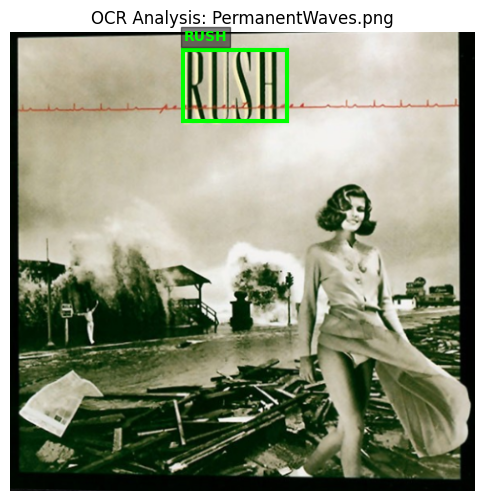

In [18]:
print(f"--- Extracted Text from {selected_file} ---")

# Setup for drawing on the image
import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(6, 6))
img = Image.open(image_path)
ax.imshow(img)

found_text = False
if result.read is not None and result.read.blocks:
    for block in result.read.blocks:
        for line in block.lines:
            found_text = True
            # 1. Print the extracted text to the console
            print(f"Detected: '{line.text}' (Confidence: {line.words[0].confidence:.2f})")
            
            # 2. Extract bounding polygon coordinates
            r = line.bounding_polygon
            x_coords = [p.x for p in r]
            y_coords = [p.y for p in r]
            
            # Draw a rectangle around the text
            width = max(x_coords) - min(x_coords)
            height = max(y_coords) - min(y_coords)
            
            # Using a bright color (like lime or cyan) for better visibility against dark album covers
            rect = patches.Rectangle((min(x_coords), min(y_coords)), width, height, 
                                     linewidth=3, edgecolor='#00FF00', facecolor='none')
            ax.add_patch(rect)
            
            # Add text label above the box using ax.text
            ax.text(min(x_coords), min(y_coords) - 10, line.text, 
                     color='#00FF00', fontsize=10, fontweight='bold', 
                     bbox=dict(facecolor='black', alpha=0.5, pad=2))

if not found_text:
    print("Warning: No text blocks were detected by the Read engine for this image.")

plt.title(f"OCR Analysis: {selected_file}")
plt.axis("off")
plt.show()

### OCR on Handwritten Lyrics

--- Extracted Text from XanaduHandwritten.png ---
Handwritten Text: 'ANADU'
Handwritten Text: '"TO SEEK THE SACRED RIVER ALPH'
Handwritten Text: 'TO WALK THE CAVES OF ICE'
Handwritten Text: 'TO BREAK MY FAST ON HONEY DEW'
Handwritten Text: 'AND DRINK THE MILK OF PARADISE ... "'
Handwritten Text: 'I HAD HEARD THE WHISPERED TALES'
Handwritten Text: 'OF IMMORTALITY'
Handwritten Text: 'THE DEEPEST MYSTERY'
Handwritten Text: 'FROM AN ANCIENT BOOK, I TOOK A CLUE'
Handwritten Text: 'I SCALED THE FROZEN MOUNTAIN TOPS'
Handwritten Text: 'OF EASTERN LANDS UNKNOWN'
Handwritten Text: 'TIME AND MAN ALONE'
Handwritten Text: 'SEARCHING FOR THE LOST . XANADU'
Handwritten Text: 'dos'
Handwritten Text: 'XANADUL !'
Handwritten Text: 'TO STAND WITHIN THE PLEASURE DOME'
Handwritten Text: 'ECREED BY KUBLA KHAN'
Handwritten Text: 'TO TASTE ANEW THE FRUITS OF LIFE'
Handwritten Text: 'THE LAST IMMORTAL MAN'
Handwritten Text: 'TO FIND THE SACRED RIVER ALPH'
Handwritten Text: 'TO WALK THE CAVES OF ICE'
Handwritt

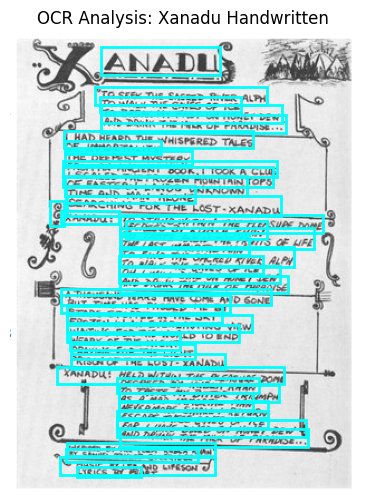

In [19]:
handwritten_image_path = "rush_lyrics/XanaduHandwritten.png"

with open(handwritten_image_path, "rb") as f:
    handwritten_data = f.read()

# Analyze the handwritten image
handwritten_result = client.analyze(
    image_data=handwritten_data,
    visual_features=[VisualFeatures.READ]
)

# Display results for handwritten text
print(f"--- Extracted Text from XanaduHandwritten.png ---")
fig, ax = plt.subplots(figsize=(6, 6))
img = Image.open(handwritten_image_path)
ax.imshow(img)

if handwritten_result.read is not None:
    for block in handwritten_result.read.blocks:
        for line in block.lines:
            print(f"Handwritten Text: '{line.text}'")
            r = line.bounding_polygon
            x_coords = [p.x for p in r]
            y_coords = [p.y for p in r]
            
            # Draw overlay
            rect = patches.Rectangle((min(x_coords), min(y_coords)), 
                                     max(x_coords) - min(x_coords), 
                                     max(y_coords) - min(y_coords), 
                                     linewidth=2, edgecolor='cyan', facecolor='none')
            ax.add_patch(rect)
else:
    print("No handwriting detected.")

plt.title("OCR Analysis: Xanadu Handwritten")
plt.axis("off")
plt.show()